#**Business performance: Qwen vs Gemma**

### **How did both models perform the water vending business operations for 30 days of simulation?**

* Note: Both models had complete control to run business with challenges/ events thrown at them during each day of simulation.

#### **Import packages and load the json files**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load JSON files
qwen = pd.read_json("qwen_logs.json")
gemma = pd.read_json("gemma_logs.json")

# Add model identifier
qwen["model"] = "Qwen"
gemma["model"] = "Gemma"

# Combine
df = pd.concat([qwen, gemma], ignore_index=True)

df.head()

,timestamp,day,cash,inventory,selling_price,supplier_price,reputation,total_sales,total_profit,model
0,2026-08-14 14:14:06,1,500.0,20,3.0,2,100,0,0.0,Qwen
1,2026-08-14 14:14:06,2,391.0,107,7.0,2,100,13,65.0,Qwen
2,2026-08-14 14:43:53,3,510.0,90,7.0,2,100,30,150.0,Qwen
3,2026-08-14 15:02:22,4,580.0,80,7.0,2,100,40,200.0,Qwen
4,2026-08-14 15:18:36,5,685.0,65,7.0,2,100,55,275.0,Qwen


In [ ]:
df.tail()

,timestamp,day,cash,inventory,selling_price,supplier_price,reputation,total_sales,total_profit,model
57,2026-08-16 10:19:07,27,766.0,135,4.0,2,100,345,500.0,Gemma
58,2026-08-16 10:35:26,28,814.0,123,4.0,2,100,357,524.0,Gemma
59,2026-08-16 11:07:09,29,862.0,111,4.0,2,100,369,548.0,Gemma
60,2026-08-16 11:22:52,30,922.0,96,4.0,2,100,384,578.0,Gemma
61,2026-08-16 11:42:44,31,240.0,453,6.0,2,100,392,610.0,Gemma


### **Which model made lot of cash?**

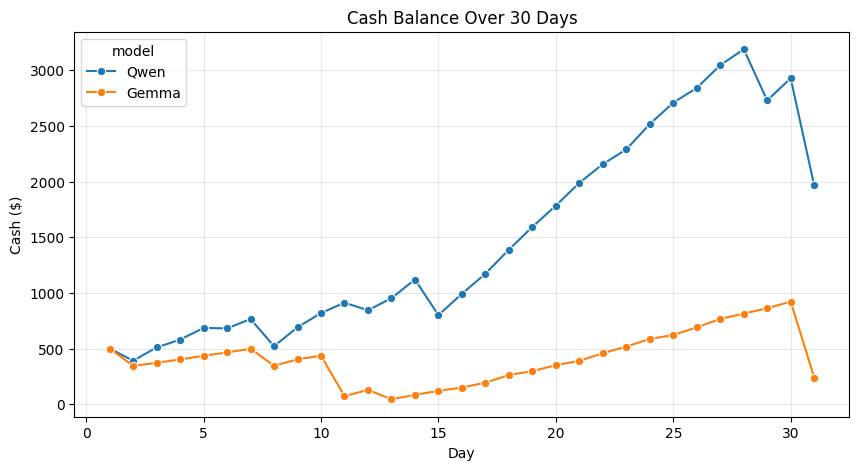

In [ ]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=df,
    x="day",
    y="cash",
    hue="model",
    marker="o"
)

plt.title("Cash Balance Over 30 Days")
plt.xlabel("Day")
plt.ylabel("Cash ($)")
plt.grid(True, alpha=0.3)
plt.show()

At the end of 30 days, Qwen3.5_9b made more than thrice amount of cash than gemma4_12b  

### **Which one made the owner proud by making lot of profit?**

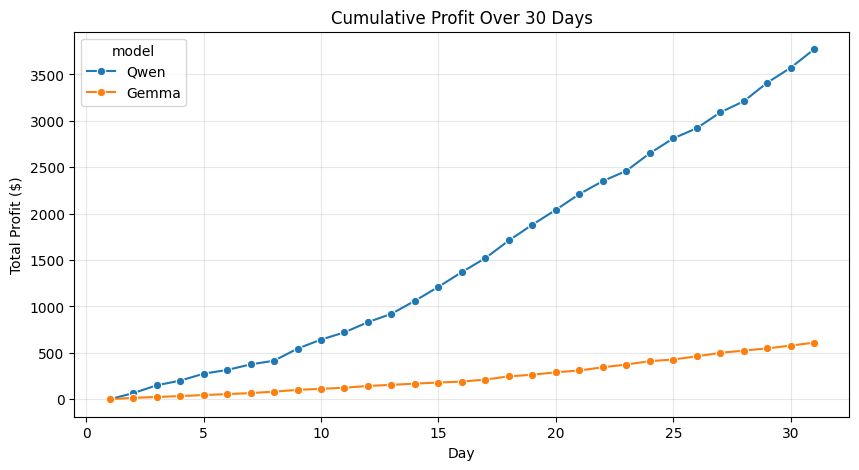

In [ ]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=df,
    x="day",
    y="total_profit",
    hue="model",
    marker="o"
)

plt.title("Cumulative Profit Over 30 Days")
plt.xlabel("Day")
plt.ylabel("Total Profit ($)")
plt.grid(True, alpha=0.3)
plt.show()

Qwen3.5_9b made more than 3500 dollars of profit, where gemma4_12b made around 600 dollars

### **who bought the most inventory?**

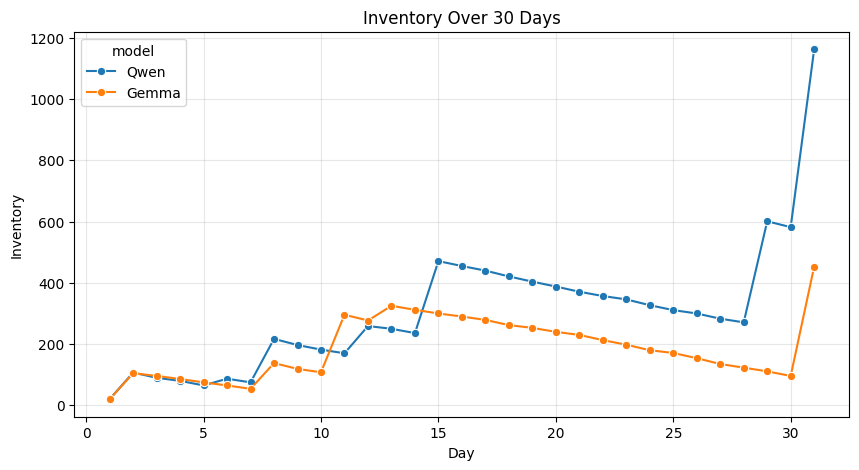

In [ ]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=df,
    x="day",
    y="inventory",
    hue="model",
    marker="o"
)

plt.title("Inventory Over 30 Days")
plt.xlabel("Day")
plt.ylabel("Inventory")
plt.grid(True, alpha=0.3)
plt.show()

Again it is qwen that bought a lot of inventory, buying drastically as the days progressed comparatively to gemma.

### **Which model was lenient and which one was aggressive when it came to selling price?**

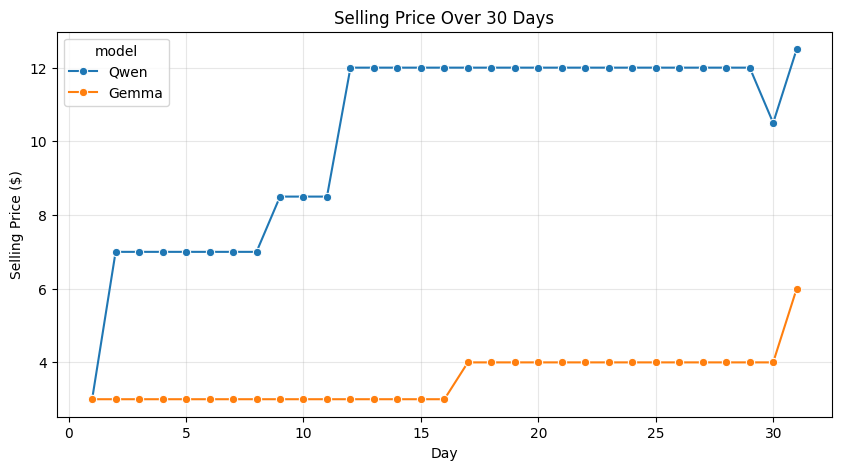

In [ ]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=df,
    x="day",
    y="selling_price",
    hue="model",
    marker="o"
)

plt.title("Selling Price Over 30 Days")
plt.xlabel("Day")
plt.ylabel("Selling Price ($)")
plt.grid(True, alpha=0.3)
plt.show()

It can be seen that qwen was quiet aggressive right from the day one and increased the selling price and it kept increasing the price at regular intervals. where gemma sold at moderate price.

### **How many bottles were sold?**

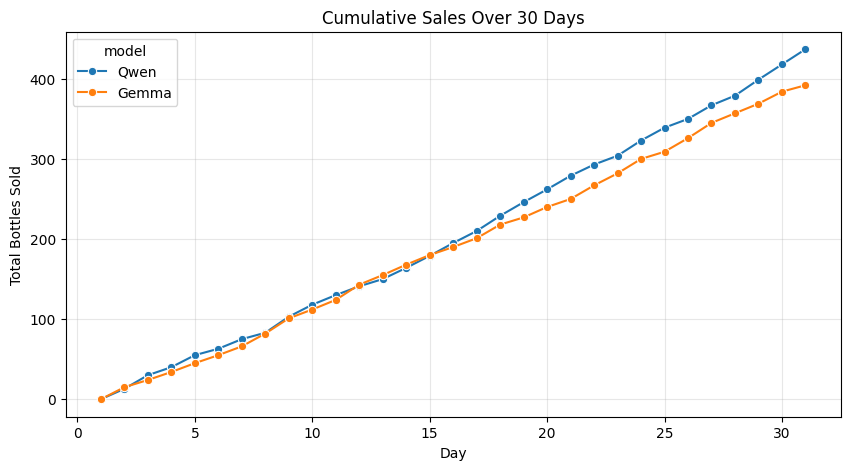

In [ ]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=df,
    x="day",
    y="total_sales",
    hue="model",
    marker="o"
)

plt.title("Cumulative Sales Over 30 Days")
plt.xlabel("Day")
plt.ylabel("Total Bottles Sold")
plt.grid(True, alpha=0.3)
plt.show()

The number of bottles sold by both models was relatively same during 30 days.

### **Overall summary**

In [ ]:
final = (
    df.sort_values("day")
      .groupby("model")
      .tail(1)
)

final

,timestamp,day,cash,inventory,selling_price,supplier_price,reputation,total_sales,total_profit,model
30,2026-08-14 21:38:40,31,1965.0,1163,12.5,2,100,437,3771.5,Qwen
61,2026-08-16 11:42:44,31,240.0,453,6.0,2,100,392,610.0,Gemma


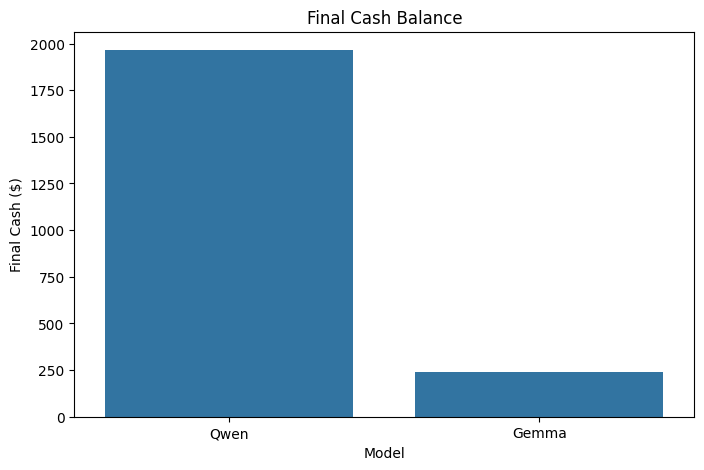

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=final,
    x="model",
    y="cash"
)

plt.title("Final Cash Balance")
plt.xlabel("Model")
plt.ylabel("Final Cash ($)")
plt.show()

In [ ]:
summary = (
    final[
        [
            "model",
            "cash",
            "inventory",
            "selling_price",
            "reputation",
            "total_sales",
            "total_profit"
        ]
    ]
    .set_index("model")
)

summary

,cash,inventory,selling_price,reputation,total_sales,total_profit
model,,,,,,
Qwen,1965.0,1163,12.5,100,437,3771.5
Gemma,240.0,453,6.0,100,392,610.0


**Overall qwen performed better than gemma, but each model confronted its own set of challenges.**